## Setup


In [1]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd

ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
COMBINED_DIR = RESULTS_DIR / "combined"
BENCHMARKS_DIR = RESULTS_DIR / "benchmarks"
COINTEGRATION_DIR = ROOT.parent / "cointegration"
NOTE_ROOT = ROOT.parents[3] / "note"

importlib.invalidate_caches()
sys.modules.pop("utils", None)

sys.path.insert(0, str(COINTEGRATION_DIR))
from utils import (
    PERFORMANCE_FORMATTERS,
    build_performance_summary,
    backtest_threshold_rebalance,
    build_combined_backtest,
    build_threshold_rebalance_backtest,
    combine_strategy_returns_drift,
    load_strategy_portfolios,
    load_benchmarks_for_portfolios,
    load_drift_outputs,
    plot_equity_comparison,
    plot_metric_comparison,
    plot_weight_drift,
    plot_weight_deviation_heatmap,
    save_combined_outputs,
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_DIR.mkdir(parents=True, exist_ok=True)
BENCHMARKS_DIR.mkdir(parents=True, exist_ok=True)

## Load Strategy Portfolios


In [2]:
EXCLUDE_STRATEGIES = {"combined", "tx_daytrade_wrong"}

portfolios = load_strategy_portfolios(
    RESULTS_DIR,
    exclude_strategies=EXCLUDE_STRATEGIES,
)

print(f"loaded strategies: {list(portfolios)}")
print(f"excluded strategies: {sorted(EXCLUDE_STRATEGIES)}")

loaded strategies: ['cointegration_basis', 'tx_daytrade']
excluded strategies: ['combined', 'tx_daytrade_wrong']


## Combine Returns


In [22]:
REFRESH_BENCHMARKS = False

# Choose which strategies or benchmark assets go into combined.
# Set to None to include every available strategy and benchmark.
COMBINED_SERIES = [
    "cointegration_basis",
    "tx_daytrade",
    "0050_buy_hold",
    "gold_buy_hold",
    "qqq_buy_hold",
    "bitcoin_buy_hold"
]

# Weight methods: "equal", "custom", or "risk_parity".
WEIGHT_METHOD = "risk_parity"
COMBINE_MODE = "drift"  # "constant" rebalances every period; "drift" lets weights float.
CUSTOM_WEIGHTS = None
RISK_PARITY_LOOKBACK = None  # None uses all available returns; use 252 for about one trading year.
RISK_PARITY_MIN_WEIGHT = 0.0
RISK_PARITY_MAX_WEIGHT = 1.0

# Set this to True when the official combined backtest should use threshold rebalancing.
USE_THRESHOLD_REBALANCE_AS_COMBINED = False
REBALANCE_THRESHOLD = 0.05
REBALANCE_COST_RATES = {
    "cointegration_basis": 0.0,
    "tx_daytrade": 0.0,
    "0050_buy_hold": 0.001425 + 0.003,
    "gold_buy_hold": 0.001,
    "qqq_buy_hold": 0.001,
    "bitcoin_buy_hold": 0.001,
}
RC_COVARIANCE_LOOKBACK = None

benchmark_portfolios = load_benchmarks_for_portfolios(
    portfolios,
    cache_dir=BENCHMARKS_DIR,
    note_root=NOTE_ROOT,
    refresh=REFRESH_BENCHMARKS,
)

combined_result = build_combined_backtest(
    portfolios,
    benchmark_portfolios,
    combined_series=COMBINED_SERIES,
    weight_method=WEIGHT_METHOD,
    combine_mode=COMBINE_MODE,
    custom_weights=CUSTOM_WEIGHTS,
    risk_parity_lookback=RISK_PARITY_LOOKBACK,
    risk_parity_min_weight=RISK_PARITY_MIN_WEIGHT,
    risk_parity_max_weight=RISK_PARITY_MAX_WEIGHT,
)

combined_candidates = combined_result["combined_candidates"]
combined_inputs = combined_result["combined_inputs"]
strategy_returns = combined_result["strategy_returns"]
weights = combined_result["weights"]
combined_portfolio = combined_result["combined_portfolio"]
drift_weights = combined_result["drift_weights"]
target_weight_frame = combined_result["target_weight_frame"]
weight_deviation = combined_result["weight_deviation"]

(
    _,
    _,
    natural_drift_portfolio,
    natural_drift_weights,
    natural_target_weight_frame,
    natural_weight_deviation,
) = combine_strategy_returns_drift(
    combined_inputs,
    weights=weights,
)

selected_threshold_rebalance = None

if USE_THRESHOLD_REBALANCE_AS_COMBINED:
    selected_threshold_rebalance = build_threshold_rebalance_backtest(
        strategy_returns,
        weights,
        REBALANCE_THRESHOLD,
        cost_rates=REBALANCE_COST_RATES,
        covariance_lookback=RC_COVARIANCE_LOOKBACK,
    )
    combined_portfolio = selected_threshold_rebalance["portfolio"]
    drift_weights = selected_threshold_rebalance["rebalance_weights"]
    target_weight_frame = selected_threshold_rebalance["target_weight_frame"]
    weight_deviation = selected_threshold_rebalance["weight_deviation"]

print(f"available for combined: {list(combined_candidates)}")
print(f"combined holdings: {list(combined_inputs)}")
print(f"weight method: {WEIGHT_METHOD}")
print(f"combine mode: {COMBINE_MODE}")
print(f"threshold rebalance as combined: {USE_THRESHOLD_REBALANCE_AS_COMBINED}")
if USE_THRESHOLD_REBALANCE_AS_COMBINED:
    print(f"rebalance threshold: {REBALANCE_THRESHOLD:.2%}")
display(weights.rename("target_weight").to_frame())
if drift_weights is not None:
    display(drift_weights.tail().style.format("{:.2%}"))
    display(weight_deviation.abs().tail().style.format("{:.2%}"))
display(strategy_returns.corr())

available for combined: ['cointegration_basis', 'tx_daytrade', '0050_buy_hold', 'sp500_buy_hold', 'gold_buy_hold', 'qqq_buy_hold', 'bitcoin_buy_hold', 'fidelity_global_income_buy_hold']
combined holdings: ['cointegration_basis', 'tx_daytrade', '0050_buy_hold', 'gold_buy_hold', 'qqq_buy_hold', 'bitcoin_buy_hold']
weight method: risk_parity
combine mode: drift
threshold rebalance as combined: False


,target_weight
cointegration_basis,0.617864
tx_daytrade,0.132459
0050_buy_hold,0.071635
gold_buy_hold,0.091073
qqq_buy_hold,0.060186
bitcoin_buy_hold,0.026783


,cointegration_basis,tx_daytrade,0050_buy_hold,gold_buy_hold,qqq_buy_hold,bitcoin_buy_hold
2026-05-26 05:00:00,45.52%,11.34%,11.91%,10.90%,8.55%,11.78%
2026-05-26 06:00:00,45.52%,11.34%,11.91%,10.90%,8.55%,11.78%
2026-05-26 07:00:00,45.52%,11.34%,11.91%,10.90%,8.55%,11.78%
2026-05-26 08:00:00,45.52%,11.34%,11.91%,10.90%,8.55%,11.78%
2026-05-26 09:00:00,45.52%,11.34%,11.91%,10.90%,8.55%,11.78%


,cointegration_basis,tx_daytrade,0050_buy_hold,gold_buy_hold,qqq_buy_hold,bitcoin_buy_hold
2026-05-26 05:00:00,16.27%,1.90%,4.74%,1.79%,2.53%,9.11%
2026-05-26 06:00:00,16.27%,1.90%,4.74%,1.79%,2.53%,9.11%
2026-05-26 07:00:00,16.27%,1.90%,4.74%,1.79%,2.53%,9.11%
2026-05-26 08:00:00,16.27%,1.90%,4.74%,1.79%,2.53%,9.11%
2026-05-26 09:00:00,16.27%,1.90%,4.74%,1.79%,2.53%,9.11%


,cointegration_basis,tx_daytrade,0050_buy_hold,gold_buy_hold,qqq_buy_hold,bitcoin_buy_hold
cointegration_basis,1.000000,0.000345,0.003447,0.015841,-0.026136,-0.004634
tx_daytrade,0.000345,1.000000,0.379232,0.072160,0.121226,0.053838
0050_buy_hold,0.003447,0.379232,1.000000,0.086730,0.119741,0.010159
gold_buy_hold,0.015841,0.072160,0.086730,1.000000,0.121370,0.100832
qqq_buy_hold,-0.026136,0.121226,0.119741,0.121370,1.000000,0.371207
bitcoin_buy_hold,-0.004634,0.053838,0.010159,0.100832,0.371207,1.000000


## Performance


,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly
cointegration_basis,81.75%,6.83%,2.59%,2.64,-3.48%,356 days,4.14,55.61%,3.31,0.10%,-0.03%,0.04%,0.42
tx_daytrade,79.20%,9.94%,11.93%,0.83,-20.08%,587 days,1.26,54.13%,1.07,0.66%,-0.62%,0.07%,0.11
combined,146.72%,10.23%,6.70%,1.53,-15.10%,783 days,1.32,55.33%,1.06,0.30%,-0.28%,0.04%,0.13
0050_buy_hold,310.06%,25.86%,22.36%,1.16,-36.38%,779 days,1.23,53.74%,1.06,1.04%,-0.99%,0.10%,0.10
sp500_buy_hold,130.80%,14.01%,20.55%,0.68,-33.92%,745 days,1.15,54.42%,0.97,0.83%,-0.86%,0.06%,0.07
gold_buy_hold,195.20%,18.48%,18.64%,0.99,-20.87%,1211 days,1.20,55.39%,0.97,0.81%,-0.84%,0.07%,0.09
qqq_buy_hold,250.56%,21.74%,24.93%,0.87,-35.12%,715 days,1.18,56.26%,0.92,1.06%,-1.16%,0.09%,0.09
bitcoin_buy_hold,985.48%,29.32%,50.17%,0.58,-76.63%,846 days,1.16,50.90%,1.12,2.23%,-2.00%,0.15%,0.07
fidelity_global_income_buy_hold,74.09%,8.76%,14.63%,0.60,-29.60%,712 days,1.13,53.90%,0.96,0.63%,-0.66%,0.04%,0.06


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'assets'}, xlabel='Time', ylabel='Equity (Start = 1)'>)

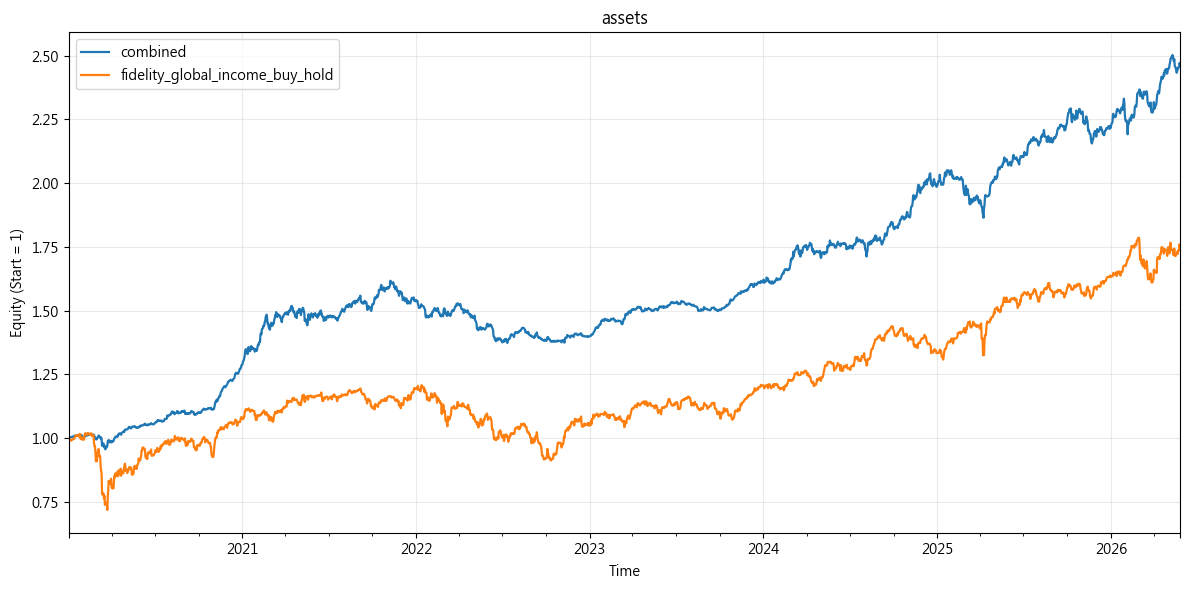

In [23]:
benchmark_returns = pd.concat(
    {name: portfolio["strategy_return"] for name, portfolio in benchmark_portfolios.items()},
    axis=1,
)

comparison_portfolios = {
    **portfolios,
    "combined": combined_portfolio,
    **benchmark_portfolios,
}

summary = build_performance_summary(comparison_portfolios, freq="D")

# Set to None to plot everything, or list the exact rows you want on the chart.
PLOT_SERIES = [
    # "cointegration_basis",
    # "tx_daytrade",
    # "0050_buy_hold",
    # "gold_buy_hold",
    # "qqq_buy_hold",
    "combined",
    "fidelity_global_income_buy_hold",
]
# EQUITY_PLOT_TITLE = "Strategy vs Buy-and-Hold Benchmarks"
EQUITY_PLOT_TITLE = "assets"

styled_summary = summary.style.format(PERFORMANCE_FORMATTERS)
display(styled_summary)
plot_equity_comparison(
    comparison_portfolios,
    include=PLOT_SERIES,
    title=EQUITY_PLOT_TITLE,
)

## Threshold Rebalance


In [15]:
THRESHOLDS = np.arange(0.01, 0.21, 0.005)
# Uses REBALANCE_COST_RATES and RC_COVARIANCE_LOOKBACK defined in Combine Returns.

threshold_summary, threshold_details = backtest_threshold_rebalance(
    strategy_returns,
    weights,
    THRESHOLDS,
    cost_rates=REBALANCE_COST_RATES,
    covariance_lookback=RC_COVARIANCE_LOOKBACK,
)

threshold_summary.to_csv(COMBINED_DIR / "threshold_rebalance_summary.csv")
display(
    threshold_summary.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe": "{:.2f}",
        "MDD": "{:.2%}",
        "Turnover": "{:.2f}",
        "Rebalance Count": "{:.0f}",
        "Average RC Deviation": "{:.2%}",
    })
)


,年化報酬,年化波動,Sharpe,MDD,Turnover,再平衡次數,平均 RC 偏離
Threshold,,,,,,,
0.010000,0.147340,0.049309,2.99,-6.97%,1.88,67,0.009633
0.015000,0.146423,0.049406,2.96,-7.19%,1.29,32,0.012767
0.020000,0.149416,0.049748,3.00,-6.58%,1.23,23,0.017299
0.025000,0.146803,0.050445,2.91,-7.82%,0.91,15,0.018674
0.030000,0.147439,0.051013,2.89,-8.07%,1.01,14,0.022848
0.035000,0.148134,0.051827,2.86,-8.28%,0.75,9,0.030109
0.040000,0.150432,0.051433,2.92,-8.22%,0.94,10,0.028257
0.045000,0.152346,0.051432,2.96,-7.62%,0.87,8,0.028135
0.050000,0.149908,0.051685,2.90,-8.20%,0.68,6,0.032569


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Threshold vs Sharpe'}, xlabel='Threshold', ylabel='Sharpe'>)

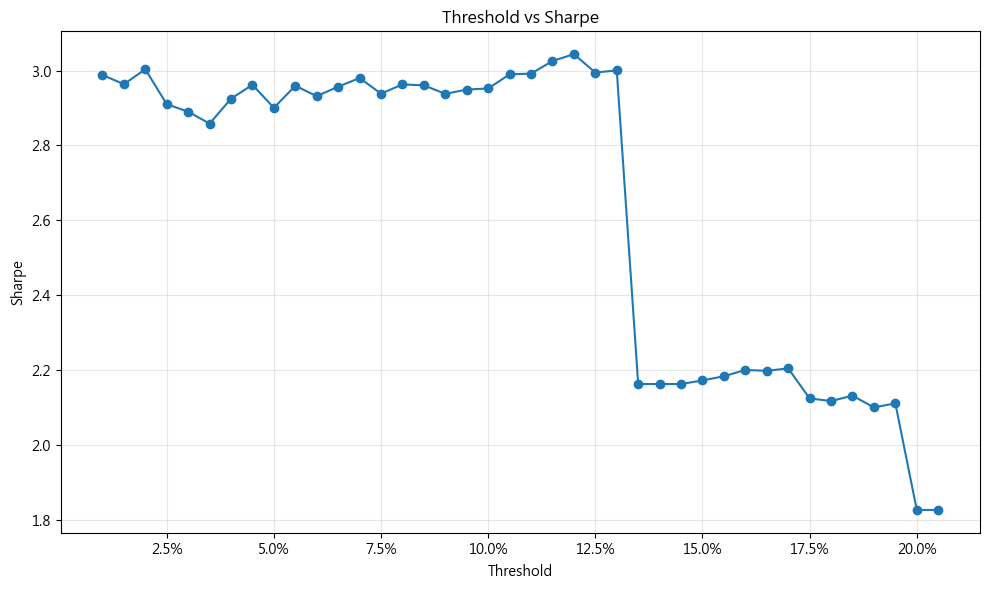

In [6]:
THRESHOLD_PLOT_TITLE = "Threshold vs Sharpe"

plot_metric_comparison(
    threshold_summary,
    y="Sharpe",
    x_percent=True,
    title=THRESHOLD_PLOT_TITLE,
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Natural Weight Drift (No Rebalance)'}, xlabel='Time', ylabel='Weight'>)

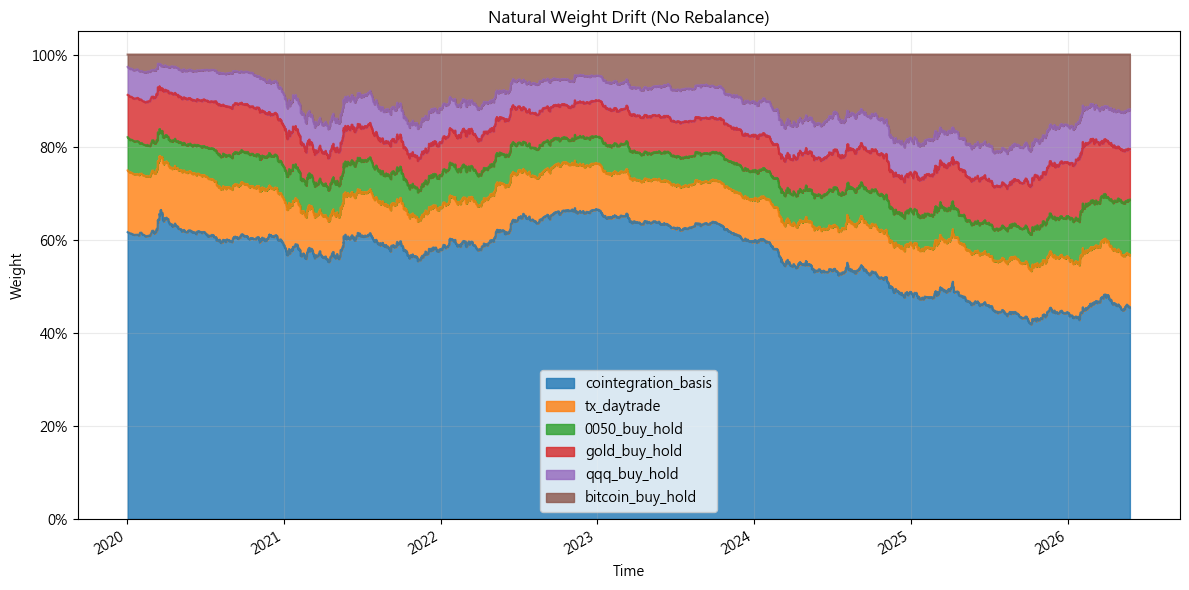

In [7]:
# Natural drift from target weights; this is not threshold-rebalanced.
NATURAL_WEIGHT_DRIFT_TITLE = "Natural Weight Drift (No Rebalance)"

plot_weight_drift(
    natural_drift_weights,
    title=NATURAL_WEIGHT_DRIFT_TITLE,
)


## backtest

combined uses threshold rebalance: 10.00%


,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly
cointegration_basis,81.75%,10.05%,3.12%,3.22,-3.48%,356 days,4.14,55.61%,3.31,0.10%,-0.03%,0.04%,0.42
tx_daytrade,79.20%,9.55%,11.70%,0.82,-20.08%,587 days,1.26,54.13%,1.07,0.66%,-0.62%,0.07%,0.11
combined,149.97%,15.40%,5.10%,3.02,-6.45%,487 days,1.64,57.08%,1.23,0.18%,-0.14%,0.04%,0.22
0050_buy_hold,310.06%,24.69%,21.89%,1.13,-36.38%,779 days,1.23,53.74%,1.06,1.04%,-0.99%,0.10%,0.10
sp500_buy_hold,130.80%,13.97%,20.51%,0.68,-33.92%,745 days,1.15,54.42%,0.97,0.83%,-0.86%,0.06%,0.07
gold_buy_hold,195.20%,18.44%,18.62%,0.99,-20.87%,1211 days,1.20,55.39%,0.97,0.81%,-0.84%,0.07%,0.09
qqq_buy_hold,250.56%,21.67%,24.88%,0.87,-35.12%,715 days,1.18,56.26%,0.92,1.06%,-1.16%,0.09%,0.09
bitcoin_buy_hold,985.48%,45.19%,60.39%,0.75,-76.63%,846 days,1.16,50.90%,1.12,2.23%,-2.00%,0.15%,0.07
fidelity_global_income_buy_hold,74.09%,9.06%,14.85%,0.61,-29.60%,712 days,1.13,53.90%,0.96,0.63%,-0.66%,0.04%,0.06


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Threshold Rebalanced Weight Drift'}, xlabel='Time', ylabel='Weight'>)

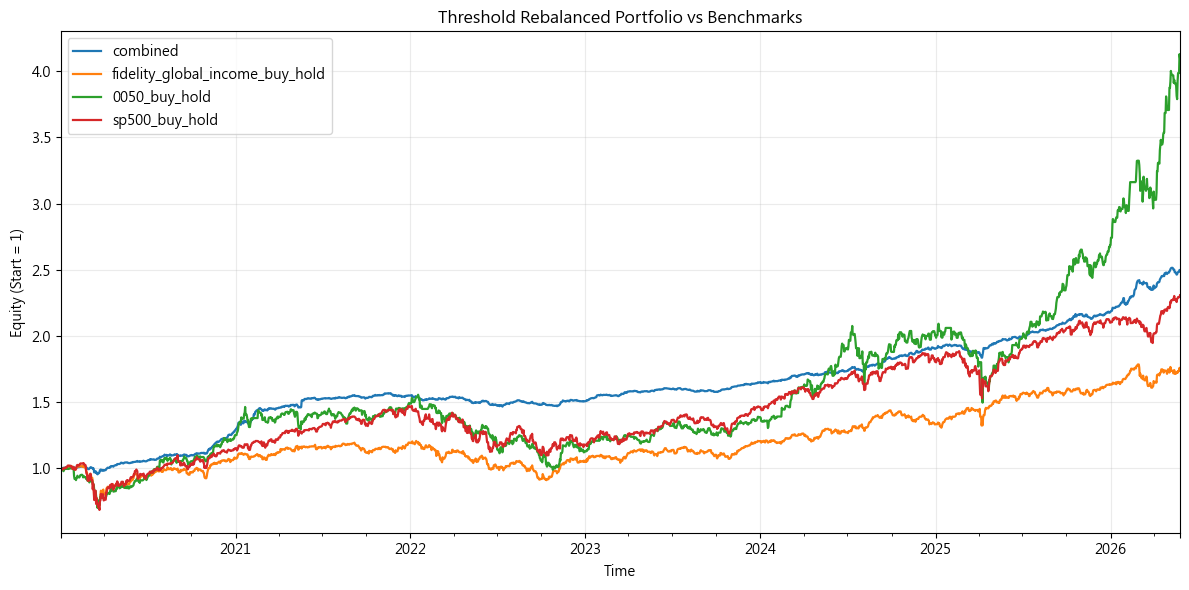

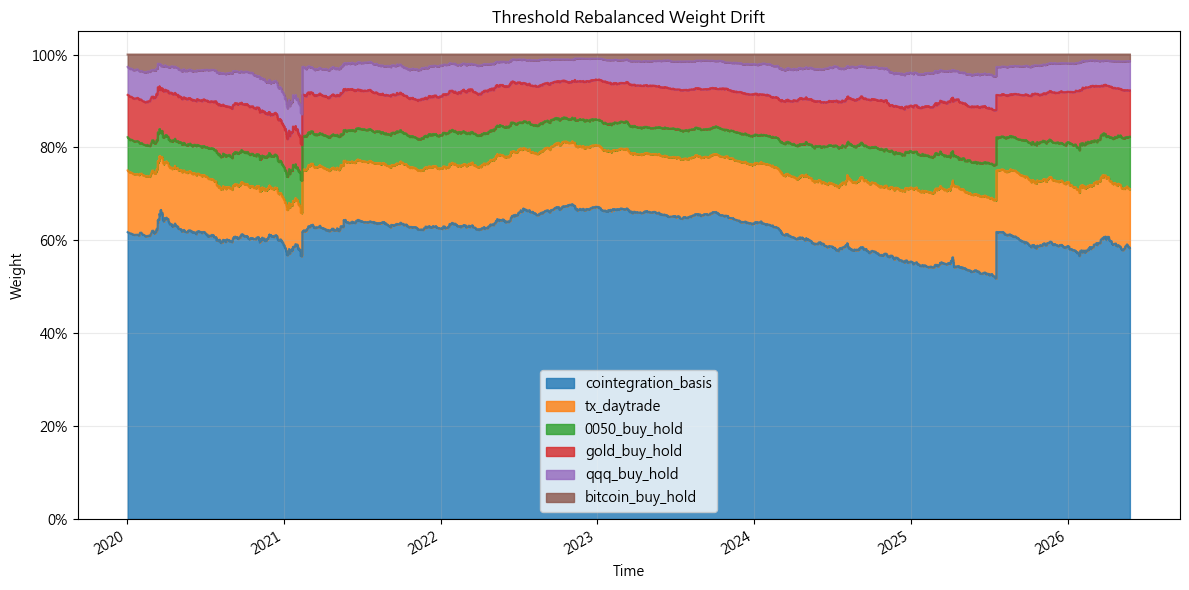

In [8]:
USE_THRESHOLD_REBALANCE_AS_COMBINED = True
REBALANCE_THRESHOLD = 0.10

if USE_THRESHOLD_REBALANCE_AS_COMBINED:
    selected_threshold_rebalance = build_threshold_rebalance_backtest(
        strategy_returns,
        weights,
        REBALANCE_THRESHOLD,
        cost_rates=REBALANCE_COST_RATES,
        covariance_lookback=RC_COVARIANCE_LOOKBACK,
    )
    combined_portfolio = selected_threshold_rebalance["portfolio"]
    drift_weights = selected_threshold_rebalance["rebalance_weights"]
    target_weight_frame = selected_threshold_rebalance["target_weight_frame"]
    weight_deviation = selected_threshold_rebalance["weight_deviation"]
    print(f"combined uses threshold rebalance: {REBALANCE_THRESHOLD:.2%}")

benchmark_returns = pd.concat(
    {name: portfolio["strategy_return"] for name, portfolio in benchmark_portfolios.items()},
    axis=1,
)

comparison_portfolios = {
    **portfolios,
    "combined": combined_portfolio,
    **benchmark_portfolios,
}

summary = build_performance_summary(comparison_portfolios, freq="D")

# Set to None to plot everything, or list the exact rows you want on the chart.
PLOT_SERIES = [
    "combined",
    "fidelity_global_income_buy_hold",
    "0050_buy_hold",
    "sp500_buy_hold",
]

EQUITY_PLOT_TITLE = "Threshold Rebalanced Portfolio vs Benchmarks"

styled_summary = summary.style.format(PERFORMANCE_FORMATTERS)
display(styled_summary)
plot_equity_comparison(
    comparison_portfolios,
    include=PLOT_SERIES,
    title=EQUITY_PLOT_TITLE,
)

drift_weights, target_weight_frame, weight_deviation = load_drift_outputs(COMBINED_DIR)

REBALANCED_WEIGHT_DRIFT_TITLE = "Threshold Rebalanced Weight Drift"

plot_weight_drift(
    drift_weights,
    title=REBALANCED_WEIGHT_DRIFT_TITLE,
)

## Save Combined Portfolio


In [9]:
saved_paths = save_combined_outputs(
    combined_dir=COMBINED_DIR,
    combined_portfolio=combined_portfolio,
    summary=summary,
    weights=weights,
    strategy_returns=strategy_returns,
    benchmark_returns=benchmark_returns,
    drift_weights=drift_weights,
    target_weights=target_weight_frame,
    weight_deviation=weight_deviation,
)

saved_paths

{'portfolio': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/portfolio.parquet'),
 'summary': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/summary.csv'),
 'weights': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/weights.csv'),
 'strategy_returns': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/strategy_returns.parquet'),
 'benchmark_returns': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/benchmark_returns.parquet'),
 'drift_weights': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/drift_weights.parquet'),
 'target_weights': WindowsPath('D:/Github/Personal-Project/ndhu/portfolio_management/aggregate/results/combined/target_weights.parquet'),
 'weight_deviation': WindowsPath('D:/Github/Personal-Project/ndhu/portfo